# NBAIoT — ML Classification (Universal)

**Dataset:** [N-BaIoT on Kaggle](https://www.kaggle.com/datasets/mkashifn/nbaiot-dataset)  
**Задача 1:** Бинарная классификация — benign vs malicious  
**Задача 2:** Мультиклассовая — определение типа атаки  

---
### Как настроить ноутбук
Все параметры — в ячейке **«Конфигурация»**:
| Параметр | Что меняет |
|---|---|
| `SAMPLE_FRACTION` | Доля датасета (0.0–1.0). `0.1` = 10%, `1.0` = весь датасет |
| `TEST_SIZE` | Доля тестовой выборки от отобранного объёма |
| `N_PCA_COMPONENTS` | Кол-во PCA-компонент (17 → 95% дисперсии) |
| `MODELS` | Словарь алгоритмов — добавляйте/удаляйте без изменения остального кода |

## 0. Конфигурация железа

In [2]:
import platform, subprocess
import psutil

print("=" * 62)
print("  КОНФИГУРАЦИЯ СИСТЕМЫ")
print("=" * 62)
print(f"ОС                : {platform.system()} {platform.release()}")
print(f"Версия ОС         : {platform.version()}")
print(f"Архитектура       : {platform.machine()}")
print(f"Процессор         : {platform.processor()}")
print(f"Python            : {platform.python_version()}")

print(f"Ядра CPU (физ.)   : {psutil.cpu_count(logical=False)}")
print(f"Ядра CPU (лог.)   : {psutil.cpu_count(logical=True)}")
try:
    freq = psutil.cpu_freq()
    print(f"Частота CPU макс. : {freq.max:.0f} МГц")
except Exception:
    pass

ram = psutil.virtual_memory()
print(f"RAM всего         : {ram.total / 1024**3:.2f} ГБ")
print(f"RAM доступно      : {ram.available / 1024**3:.2f} ГБ")

print()
try:
    gpu_info = subprocess.check_output(
        ["nvidia-smi", "--query-gpu=name,memory.total,driver_version",
         "--format=csv,noheader"], stderr=subprocess.DEVNULL
    ).decode().strip()
    print(f"GPU               : {gpu_info}")
    print("Примечание        : XGBoost работает на CPU (device='cpu')")
except Exception:
    print("GPU               : не обнаружен")
    print("Примечание        : XGBoost работает на CPU")

print()
print("=" * 62)
print("  ВЕРСИИ БИБЛИОТЕК")
print("=" * 62)
import sklearn, xgboost, numpy as np, pandas as pd
print(f"scikit-learn      : {sklearn.__version__}")
print(f"xgboost           : {xgboost.__version__}")
print(f"numpy             : {np.__version__}")
print(f"pandas            : {pd.__version__}")

  КОНФИГУРАЦИЯ СИСТЕМЫ
ОС                : Linux 5.4.0-216-generic
Версия ОС         : #236-Ubuntu SMP Fri Apr 11 19:53:21 UTC 2025
Архитектура       : x86_64
Процессор         : x86_64
Python            : 3.10.12
Ядра CPU (физ.)   : 16
Ядра CPU (лог.)   : 32
Частота CPU макс. : 0 МГц
RAM всего         : 251.89 ГБ
RAM доступно      : 248.64 ГБ

GPU               : не обнаружен
Примечание        : XGBoost работает на CPU

  ВЕРСИИ БИБЛИОТЕК
scikit-learn      : 1.2.2
xgboost           : 1.7.6
numpy             : 1.22.4
pandas            : 1.5.3


## 1. Импорты и конфигурация

In [24]:
import time, warnings, gc, copy
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, RobustScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# ╔══════════════════════════════════════════════════════════════╗
# ║                  ГЛОБАЛЬНЫЕ ПАРАМЕТРЫ                       ║
# ╚══════════════════════════════════════════════════════════════╝

# Путь к директории с CSV-файлами датасета
DATA_DIR = Path("../datasets")

# Доля датасета, задействованная в обучении и тестах
# Диапазон: (0.0, 1.0]. 1.0 = весь датасет, 0.1 = 10% и т.д.
# Доли датасета для эксперимента масштабирования
SAMPLE_FRACTIONS = [0.01, 0.05, 0.1] # ,0.5, 1.0 итд, пока не будем, а то долго 
# @TODO для презы заменить на [0.05, 0.1, 0.25, 0.5, 0.75, 1.0] и прогнать

# Одиночное значение для обратной совместимости с секциями 10–14
SAMPLE_FRACTION = SAMPLE_FRACTIONS[-1]  # последняя доля из массива

# Количество ядер CPU для эксперимента
# -1 означает «все доступные ядра» (передаётся в n_jobs/nthread)
N_JOBS_LIST = [1, 2, 4, 8, -1]

# Фиксированный размер датасета для эксперимента с ядрами
# (используется наибольший прогон из SAMPLE_FRACTIONS или задаётся вручную)
CORES_SAMPLE_FRACTION = SAMPLE_FRACTIONS[1]


# Доля тестовой выборки от отобранных данных
TEST_SIZE = 0.20

# Кол-во PCA-компонент (из разведочного анализа: 17 → 95% дисперсии)
N_PCA_COMPONENTS = 17

RANDOM_STATE = 42
METRICS      = ["accuracy", "precision", "recall"]

sns.set_theme(style="whitegrid", palette="muted")
print(f"Конфигурация загружена.")
print(f"  SAMPLE_FRACTIONS  = {SAMPLE_FRACTIONS}")
print(f"  (финальный прогон: {SAMPLE_FRACTION*100:.0f}% датасета)")
print(f"  N_JOBS_LIST       = {N_JOBS_LIST}")
print(f"  CORES_SAMPLE_FRACTION = {CORES_SAMPLE_FRACTION*100:.0f}% датасета")
print(f"  TEST_SIZE        = {TEST_SIZE}")
print(f"  N_PCA_COMPONENTS = {N_PCA_COMPONENTS}")
print(f"  RANDOM_STATE     = {RANDOM_STATE}")

Конфигурация загружена.
  SAMPLE_FRACTIONS  = [0.01, 0.05, 0.1]
  (финальный прогон: 10% датасета)
  N_JOBS_LIST       = [1, 2, 4, 8, -1]
  CORES_SAMPLE_FRACTION = 5% датасета
  TEST_SIZE        = 0.2
  N_PCA_COMPONENTS = 17
  RANDOM_STATE     = 42


## 2. Загрузка данных

In [5]:
BENIGN_KEYWORDS = ["benign"]

csv_files = sorted(DATA_DIR.rglob("*.csv"))
assert len(csv_files) > 0, f"CSV-файлы не найдены в {DATA_DIR}!"
print(f"Найдено CSV-файлов: {len(csv_files)}")

frames = []
for fpath in csv_files:
    df_tmp = pd.read_csv(fpath)
    stem   = fpath.stem.lower()
    parent = fpath.parent.name.lower()

    is_benign   = any(kw in stem or kw in parent for kw in BENIGN_KEYWORDS)
    clean_stem  = stem.lstrip("0123456789.").strip().replace(" ", "_")
    label_multi = "benign" if is_benign else (clean_stem or parent)

    df_tmp["label_multi"]  = label_multi
    df_tmp["label_binary"] = 0 if is_benign else 1

    frames.append(df_tmp)
    print(f"  {len(df_tmp):>8,} строк  label='{label_multi}'  [{fpath.name}]")

df = pd.concat(frames, ignore_index=True)
print(f"\nИтого загружено: {df.shape[0]:,} строк × {df.shape[1]} колонок")
del frames; gc.collect()

Найдено CSV-файлов: 89
    49,548 строк  label='benign'  [1.benign.csv]
    59,718 строк  label='gafgyt.combo'  [1.gafgyt.combo.csv]
    29,068 строк  label='gafgyt.junk'  [1.gafgyt.junk.csv]
    29,849 строк  label='gafgyt.scan'  [1.gafgyt.scan.csv]
    92,141 строк  label='gafgyt.tcp'  [1.gafgyt.tcp.csv]
   105,874 строк  label='gafgyt.udp'  [1.gafgyt.udp.csv]
   102,195 строк  label='mirai.ack'  [1.mirai.ack.csv]
   107,685 строк  label='mirai.scan'  [1.mirai.scan.csv]
   122,573 строк  label='mirai.syn'  [1.mirai.syn.csv]
   237,665 строк  label='mirai.udp'  [1.mirai.udp.csv]
    81,982 строк  label='mirai.udpplain'  [1.mirai.udpplain.csv]
    13,113 строк  label='benign'  [2.benign.csv]
    53,012 строк  label='gafgyt.combo'  [2.gafgyt.combo.csv]
    30,312 строк  label='gafgyt.junk'  [2.gafgyt.junk.csv]
    27,494 строк  label='gafgyt.scan'  [2.gafgyt.scan.csv]
    95,021 строк  label='gafgyt.tcp'  [2.gafgyt.tcp.csv]
   104,791 строк  label='gafgyt.udp'  [2.gafgyt.udp.csv]
   113

48

## 3. Вспомогательные функции

Определяются **до** цикла, чтобы быть доступными внутри него.

In [6]:
# ──────────────────────────────────────────────────────────────────────────
# Обучение и оценка одной модели
# ──────────────────────────────────────────────────────────────────────────

def train_and_evaluate(model, X_train, y_train, X_test, y_test,
                       task="binary", class_names=None,
                       algo_name="", feature_mode=""):
    """
    Обучает модель и возвращает словарь с метриками и предсказаниями.
    Использует clone() — исходный объект модели не изменяется.
    """
    avg     = "binary" if task == "binary" else "weighted"
    m       = clone(model)              # свежая копия, без предыдущих весов

    t0 = time.perf_counter()
    m.fit(X_train, y_train)
    train_time = time.perf_counter() - t0

    y_pred   = m.predict(X_test)
    accuracy  = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average=avg, zero_division=0)
    recall    = recall_score(y_test, y_pred, average=avg, zero_division=0)

    avg_tag = "" if task == "binary" else " (weighted)"
    print(f"  [{feature_mode}] {algo_name} / {task}")
    print(f"    Время обучения : {train_time:.2f}с")
    print(f"    Accuracy       : {accuracy:.4f}")
    print(f"    Precision      : {precision:.4f}{avg_tag}")
    print(f"    Recall         : {recall:.4f}{avg_tag}")

    if class_names is not None and task != "binary":
        print()
        print(classification_report(
            y_test, y_pred, target_names=class_names, zero_division=0
        ))

    return {
        "model":      m,
        "y_pred":     y_pred,
        "accuracy":   accuracy,
        "precision":  precision,
        "recall":     recall,
        "train_time": train_time,
    }


# ──────────────────────────────────────────────────────────────────────────
# Построение сводной таблицы
# ──────────────────────────────────────────────────────────────────────────

def build_summary(all_results, task):
    """
    Строит DataFrame с метриками по всем алгоритмам и режимам признаков.
    all_results: {algo_name: {feature_mode: {task: result_dict}}}
    """
    rows = []
    for algo_name, modes in all_results.items():
        for feature_mode, tasks in modes.items():
            res = tasks[task]
            rows.append({
                "Алгоритм":       algo_name,
                "Признаки":       feature_mode,
                "Accuracy":       res["accuracy"],
                "Precision":      res["precision"],
                "Recall":         res["recall"],
                "Train time (s)": res["train_time"],
            })
    return pd.DataFrame(rows)


# ──────────────────────────────────────────────────────────────────────────
# Матрица ошибок
# ──────────────────────────────────────────────────────────────────────────

def plot_confusion_matrix(y_true, y_pred, class_names, title):
    cm  = confusion_matrix(y_true, y_pred)
    sz  = max(6, len(class_names))
    fig, ax = plt.subplots(figsize=(sz, sz - 1))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names).plot(
        ax=ax, colorbar=True, cmap="Blues", xticks_rotation="vertical"
    )
    ax.set_title(title, fontsize=11)
    plt.tight_layout()
    plt.show()


# ──────────────────────────────────────────────────────────────────────────
# Универсальный bar-chart сравнения метрик
# ──────────────────────────────────────────────────────────────────────────

def plot_metrics_comparison(df_summary, task_label):
    """
    Строит сгруппированный bar-chart для всех алгоритмов из df_summary.
    Работает для любого кол-ва алгоритмов и режимов признаков.
    """
    # Создаём составной ключ «Алгоритм / Признаки» для оси X
    df_plot = df_summary.copy()
    df_plot["label"] = df_plot["Алгоритм"] + "\n" + df_plot["Признаки"]

    n_groups  = len(df_plot)
    n_metrics = len(METRICS)
    x         = np.arange(n_groups)
    width     = 0.22
    colors    = plt.rcParams['axes.prop_cycle'].by_key()['color']

    fig, ax = plt.subplots(figsize=(max(10, n_groups * 1.5), 5))
    for i, metric in enumerate(METRICS):
        vals = df_plot[metric.capitalize()].values
        bars = ax.bar(
            x + i * width, vals, width,
            label=metric.capitalize(),
            color=colors[i % len(colors)],
            edgecolor="k", linewidth=0.5
        )
        for b in bars:
            ax.text(
                b.get_x() + b.get_width() / 2,
                b.get_height() + 0.005,
                f"{b.get_height():.3f}",
                ha="center", va="bottom", fontsize=7
            )

    ax.set_xticks(x + width * (n_metrics - 1) / 2)
    ax.set_xticklabels(df_plot["label"], fontsize=8)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel("Score")
    ax.set_title(f"{task_label} — сравнение метрик", fontweight="bold")
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()


# ──────────────────────────────────────────────────────────────────────────
# Сравнение времени обучения
# ──────────────────────────────────────────────────────────────────────────

def plot_train_time_comparison(df_summary, task_label):
    """
    Pivot-bar: алгоритм vs режим признаков (full / pca).
    Работает для любого кол-ва алгоритмов.
    """
    pivot = df_summary.pivot(index="Алгоритм", columns="Признаки", values="Train time (s)")
    ax    = pivot.plot(kind="bar", figsize=(max(8, len(pivot) * 2), 4),
                       edgecolor="k", linewidth=0.5)
    ax.set_title(f"{task_label} — время обучения", fontweight="bold")
    ax.set_ylabel("Секунды")
    ax.set_xlabel("")
    plt.xticks(rotation=10)
    plt.tight_layout()
    plt.show()


# ──────────────────────────────────────────────────────────────────────────
# Важность признаков
# ──────────────────────────────────────────────────────────────────────────

def plot_feature_importance(model, feature_names, title, top_n=20):
    """
    Строит bar-chart важности признаков, если модель поддерживает feature_importances_.
    """
    if not hasattr(model, "feature_importances_"):
        print(f"  Пропущено: {title!r} не поддерживает feature_importances_")
        return

    importances = model.feature_importances_
    indices     = np.argsort(importances)[::-1][:top_n]

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(range(len(indices)), importances[indices], color="steelblue", edgecolor="k")
    ax.set_xticks(range(len(indices)))
    ax.set_xticklabels(
        [feature_names[i] for i in indices],
        rotation=45, ha="right", fontsize=8
    )
    ax.set_title(f"Топ-{top_n} важных признаков — {title}", fontweight="bold")
    ax.set_ylabel("Важность")
    plt.tight_layout()
    plt.show()


print("Все вспомогательные функции определены.")

Все вспомогательные функции определены.


## 4. Эксперимент: перебор размеров датасета

Для каждой доли из `SAMPLE_FRACTIONS` последовательно выполняется:  
выборка → предобработка → масштабирование + PCA → разбивка → обучение всех моделей.  
Все временны́е и качественные метрики фиксируются в `scaling_results`.

In [7]:
# ╔══════════════════════════════════════════════════════════════╗
# ║   ЭКСПЕРИМЕНТ: обучение на разных размерах датасета         ║
# ╚══════════════════════════════════════════════════════════════╝

# scaling_results[fraction] = {algo_name: {feature_mode: {task: result_dict}}}
scaling_results = {}

for SAMPLE_FRACTION in SAMPLE_FRACTIONS:

    print(f"\n{'#'*62}")
    print(f"  ПРОГОН: {SAMPLE_FRACTION*100:.0f}% датасета")
    print(f"{'#'*62}")

    # ── 3. Выборка ────────────────────────────────────────────────────
    total_rows = len(df)
    if SAMPLE_FRACTION < 1.0:
        df_sample, _ = train_test_split(
            df,
            train_size=SAMPLE_FRACTION,
            random_state=RANDOM_STATE,
            stratify=df["label_binary"]
        )
        df_sample = df_sample.reset_index(drop=True)
    else:
        df_sample = df.copy()

    sampled_rows = len(df_sample)
    print(f"  Строк после выборки: {sampled_rows:,} ({sampled_rows/total_rows*100:.1f}%)")

    # ── 4. Предобработка ──────────────────────────────────────────────
    FEATURE_COLS_run = [c for c in df_sample.columns if c not in ("label_binary", "label_multi")]

    df_sample = df_sample.drop_duplicates(subset=FEATURE_COLS_run).reset_index(drop=True)

    std_vals = df_sample[FEATURE_COLS_run].std()
    const_feats = std_vals[std_vals == 0].index.tolist()
    if const_feats:
        FEATURE_COLS_run = [c for c in FEATURE_COLS_run if c not in const_feats]

    df_sample[FEATURE_COLS_run] = df_sample[FEATURE_COLS_run].fillna(0)

    y_bin_run   = df_sample["label_binary"].values
    y_multi_run = df_sample["label_multi"].values

    le_run = LabelEncoder()
    y_multi_enc_run = le_run.fit_transform(y_multi_run)
    n_classes_run   = len(le_run.classes_)

    bin_counts_run      = pd.Series(y_bin_run).value_counts()
    scale_pos_weight_run = int(bin_counts_run[0]) / int(bin_counts_run[1])

    # ── 5. Масштабирование и PCA ──────────────────────────────────────
    X_raw_run = df_sample[FEATURE_COLS_run].values.astype(np.float32)

    robust_scaler_run = RobustScaler()
    X_robust_run = robust_scaler_run.fit_transform(X_raw_run).astype(np.float32)

    std_scaler_run = StandardScaler()
    X_std_run      = std_scaler_run.fit_transform(X_raw_run).astype(np.float64)

    pca_run  = PCA(n_components=N_PCA_COMPONENTS, random_state=RANDOM_STATE)
    X_pca_run = pca_run.fit_transform(X_std_run).astype(np.float32)
    del X_std_run

    # ── 6. Разбивка train / test ─────────────────────────────────────
    split_kw_b_run = dict(test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_bin_run)
    split_kw_m_run = dict(test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_multi_enc_run)

    Xr_tr_b_r, Xr_te_b_r, y_tr_b_r, y_te_b_r = train_test_split(X_robust_run, y_bin_run,       **split_kw_b_run)
    Xr_tr_m_r, Xr_te_m_r, y_tr_m_r, y_te_m_r = train_test_split(X_robust_run, y_multi_enc_run, **split_kw_m_run)
    Xp_tr_b_r, Xp_te_b_r, _,        _         = train_test_split(X_pca_run,    y_bin_run,       **split_kw_b_run)
    Xp_tr_m_r, Xp_te_m_r, _,        _         = train_test_split(X_pca_run,    y_multi_enc_run, **split_kw_m_run)

    DATASETS_run = {
        "full": {
            "binary":     (Xr_tr_b_r, Xr_te_b_r, y_tr_b_r, y_te_b_r),
            "multiclass": (Xr_tr_m_r, Xr_te_m_r, y_tr_m_r, y_te_m_r),
        },
        f"pca-{N_PCA_COMPONENTS}": {
            "binary":     (Xp_tr_b_r, Xp_te_b_r, y_tr_b_r, y_te_b_r),
            "multiclass": (Xp_tr_m_r, Xp_te_m_r, y_tr_m_r, y_te_m_r),
        },
    }

    # ── 7. Реестр алгоритмов (для данного прогона) ────────────────────
    MODELS_run = {
        "Decision Tree": {
            "binary":     DecisionTreeClassifier(max_depth=6, min_samples_leaf=5,
                              class_weight="balanced", random_state=RANDOM_STATE),
            "multiclass": DecisionTreeClassifier(max_depth=6, min_samples_leaf=5,
                              class_weight="balanced", random_state=RANDOM_STATE),
        },
        "Random Forest": {
            "binary":     RandomForestClassifier(n_estimators=100, max_depth=6,
                              min_samples_leaf=5, class_weight="balanced",
                              n_jobs=-1, random_state=RANDOM_STATE),
            "multiclass": RandomForestClassifier(n_estimators=100, max_depth=6,
                              min_samples_leaf=5, class_weight="balanced",
                              n_jobs=-1, random_state=RANDOM_STATE),
        },
        "XGBoost (CPU)": {
            "binary":     XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                              subsample=0.8, colsample_bytree=0.8,
                              scale_pos_weight=scale_pos_weight_run,
                              tree_method="hist", device="cpu",
                              eval_metric="logloss", random_state=RANDOM_STATE, verbosity=0),
            "multiclass": XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                              subsample=0.8, colsample_bytree=0.8,
                              objective="multi:softmax", num_class=n_classes_run,
                              tree_method="hist", device="cpu",
                              eval_metric="mlogloss", random_state=RANDOM_STATE, verbosity=0),
        },
    }

    # ── 8. Обучение (цикл по моделям) ────────────────────────────────
    all_results_run = {}
    for algo_name, algo_models in MODELS_run.items():
        all_results_run[algo_name] = {}
        for feature_mode, task_datasets in DATASETS_run.items():
            all_results_run[algo_name][feature_mode] = {}
            for task, (X_tr, X_te, y_tr, y_te) in task_datasets.items():
                result = train_and_evaluate(
                    model=algo_models[task],
                    X_train=X_tr, y_train=y_tr,
                    X_test=X_te,  y_test=y_te,
                    task=task,
                    algo_name=algo_name,
                    feature_mode=feature_mode,
                )
                all_results_run[algo_name][feature_mode][task] = result

    scaling_results[SAMPLE_FRACTION] = all_results_run

    # Сохраняем переменные последнего прогона для секций 10–14
    if SAMPLE_FRACTION == SAMPLE_FRACTIONS[-1]:
        all_results  = all_results_run
        DATASETS     = DATASETS_run
        FEATURE_COLS = FEATURE_COLS_run
        le           = le_run
        sampled_rows = len(df_sample)
        explained    = pca_run.explained_variance_ratio_.sum()
        CLASS_NAMES  = {
            "binary":     ["Benign", "Malicious"],
            "multiclass": le.classes_,
        }

    gc.collect()

print("\n✓ Все прогоны завершены.")
print(f"  Размеры датасета: {[f'{f*100:.0f}%' for f in SAMPLE_FRACTIONS]}")



##############################################################
  ПРОГОН: 1% датасета
##############################################################
  Строк после выборки: 70,626 (1.0%)
  [full] Decision Tree / binary
    Время обучения : 1.82с
    Accuracy       : 0.9988
    Precision      : 0.9994
    Recall         : 0.9993
  [full] Decision Tree / multiclass
    Время обучения : 1.79с
    Accuracy       : 0.7569
    Precision      : 0.7375 (weighted)
    Recall         : 0.7569 (weighted)
  [pca-17] Decision Tree / binary
    Время обучения : 0.41с
    Accuracy       : 0.9981
    Precision      : 0.9995
    Recall         : 0.9984
  [pca-17] Decision Tree / multiclass
    Время обучения : 0.56с
    Accuracy       : 0.7481
    Precision      : 0.6908 (weighted)
    Recall         : 0.7481 (weighted)
  [full] Random Forest / binary
    Время обучения : 0.70с
    Accuracy       : 0.9995
    Precision      : 0.9998
    Recall         : 0.9997
  [full] Random Forest / multiclass
    Вре

## 5. Сводные таблицы метрик (последний прогон)

Данные последней итерации `SAMPLE_FRACTIONS`.

In [8]:
df_binary    = build_summary(all_results, "binary")
df_multiclass = build_summary(all_results, "multiclass")

fmt = "{:.4f}".format

print("\n── БИНАРНАЯ КЛАССИФИКАЦИЯ ─────────────────────────────────")
print(df_binary.to_string(index=False, float_format=fmt))

print("\n── МУЛЬТИКЛАССОВАЯ КЛАССИФИКАЦИЯ ──────────────────────────")
print(df_multiclass.to_string(index=False, float_format=fmt))

# Лучшие модели
best_bin   = df_binary.loc[df_binary["Accuracy"].idxmax()]
best_multi = df_multiclass.loc[df_multiclass["Accuracy"].idxmax()]

print(f"\n★  Лучшая бинарная модель    : {best_bin['Алгоритм']} [{best_bin['Признаки']}]  "
      f"Accuracy={best_bin['Accuracy']:.4f}")
print(f"★  Лучшая мультиклас. модель : {best_multi['Алгоритм']} [{best_multi['Признаки']}]  "
      f"Accuracy={best_multi['Accuracy']:.4f}")


── БИНАРНАЯ КЛАССИФИКАЦИЯ ─────────────────────────────────
     Алгоритм Признаки  Accuracy  Precision  Recall  Train time (s)
Decision Tree     full    0.9992     0.9995  0.9997         21.6900
Decision Tree   pca-17    0.9985     0.9999  0.9985          8.0019
Random Forest     full    0.9997     0.9999  0.9997          7.9345
Random Forest   pca-17    0.9989     0.9998  0.9990          8.0000
XGBoost (CPU)     full    0.9999     1.0000  0.9999          1.6967
XGBoost (CPU)   pca-17    0.9994     0.9999  0.9994          0.7058

── МУЛЬТИКЛАССОВАЯ КЛАССИФИКАЦИЯ ──────────────────────────
     Алгоритм Признаки  Accuracy  Precision  Recall  Train time (s)
Decision Tree     full    0.8620     0.8258  0.8620         22.5664
Decision Tree   pca-17    0.7337     0.8630  0.7337          7.5840
Random Forest     full    0.8895     0.8424  0.8895          9.6062
Random Forest   pca-17    0.8363     0.8747  0.8363          7.9273
XGBoost (CPU)     full    0.9968     0.9968  0.9968         16

## 6. Графики метрик (последний прогон)

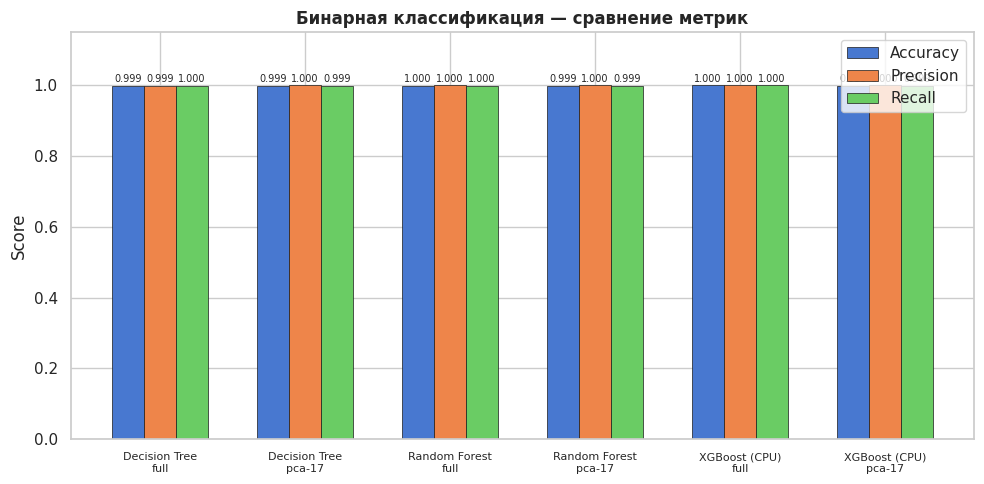

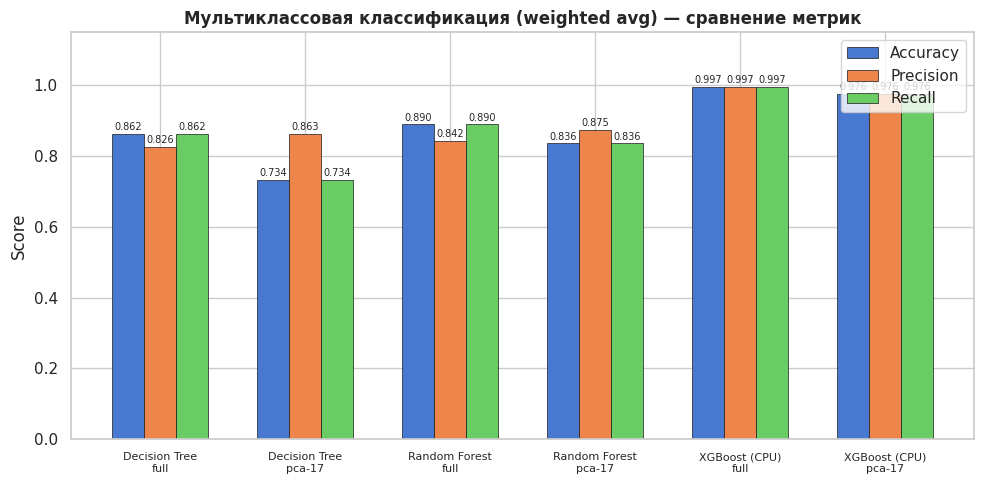

In [9]:
plot_metrics_comparison(
    df_binary,
    task_label="Бинарная классификация"
)

plot_metrics_comparison(
    df_multiclass,
    task_label="Мультиклассовая классификация (weighted avg)"
)

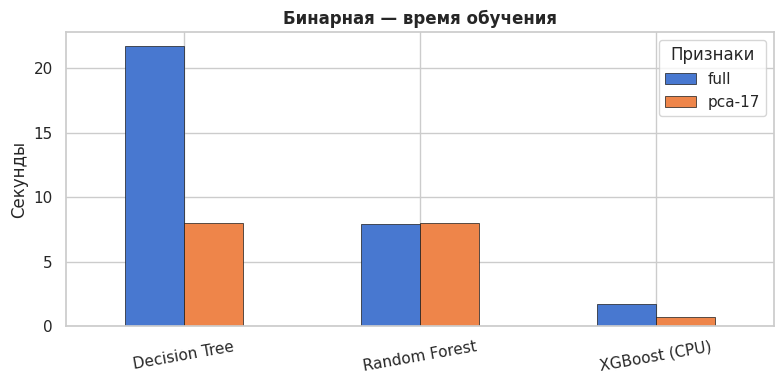

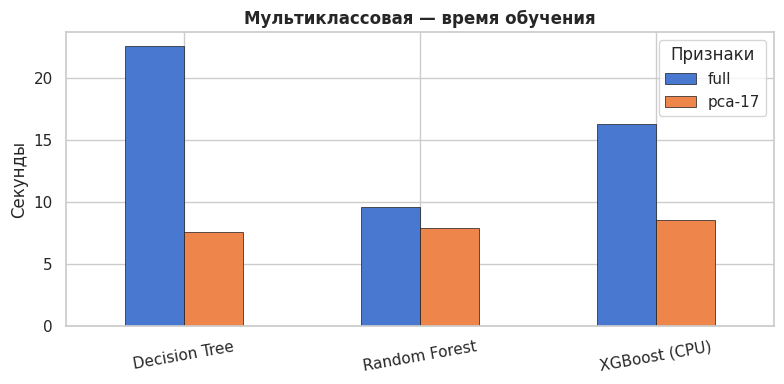

In [10]:
plot_train_time_comparison(
    df_binary,
    task_label="Бинарная"
)

plot_train_time_comparison(
    df_multiclass,
    task_label="Мультиклассовая"
)

## 7. Матрицы ошибок

Генерируются **автоматически** для каждого алгоритма × каждого режима признаков.

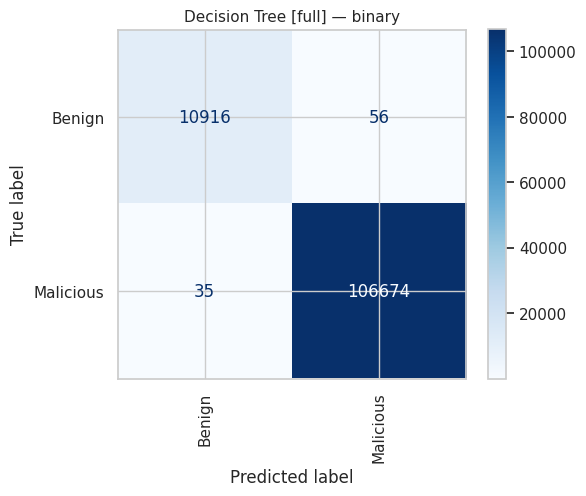

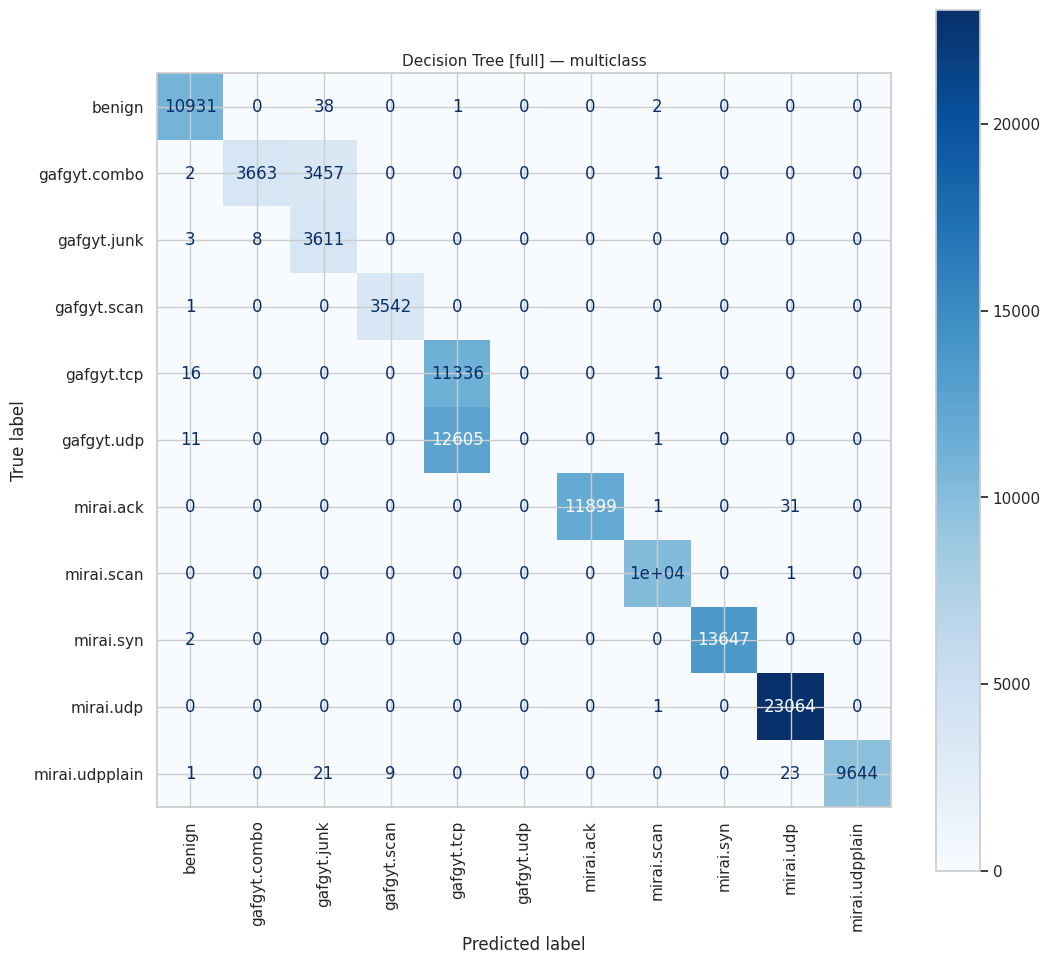

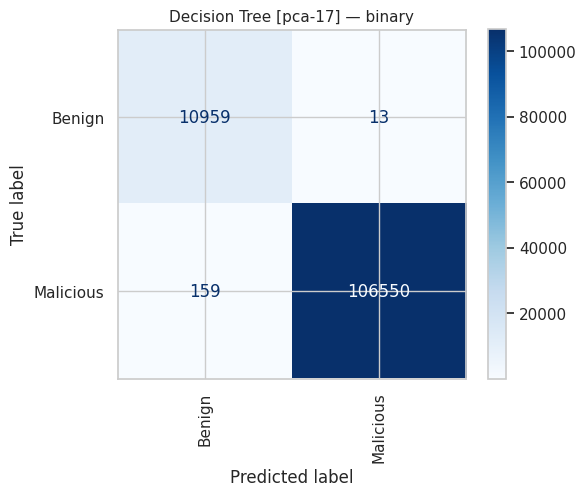

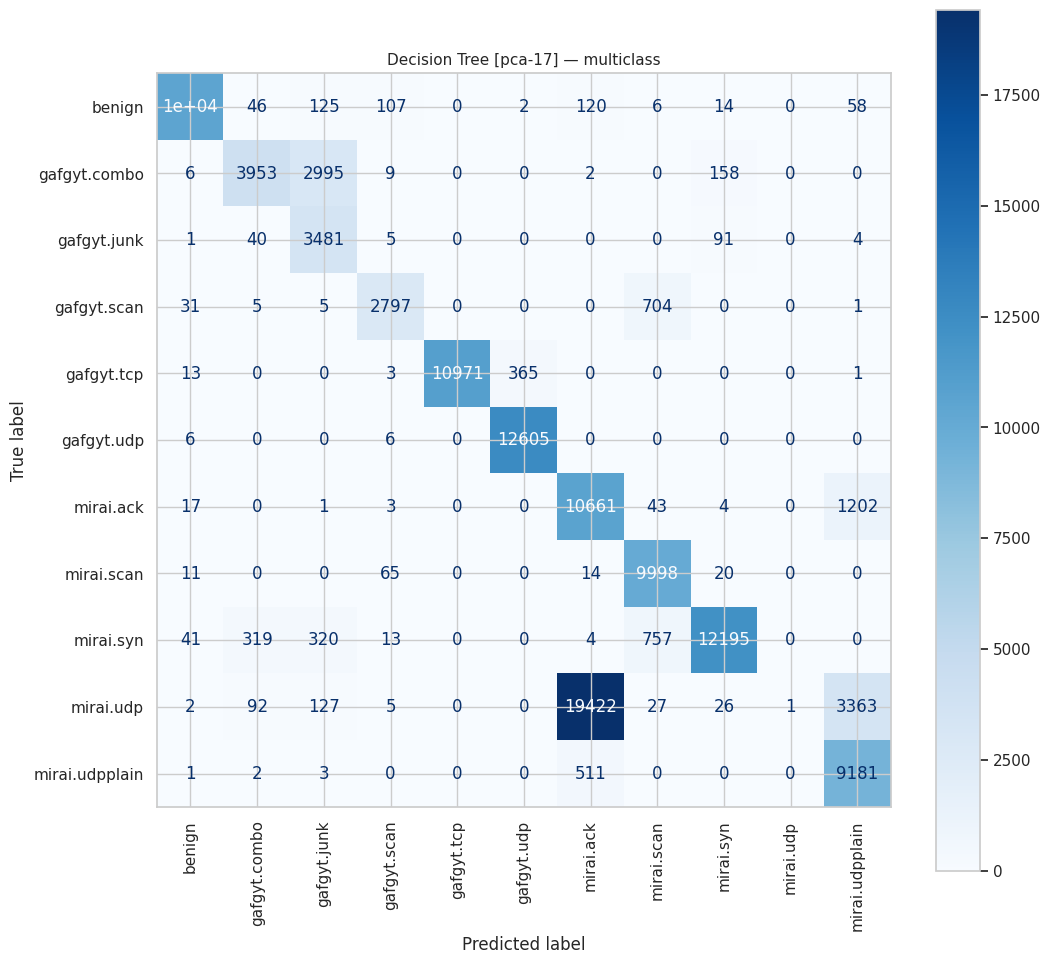

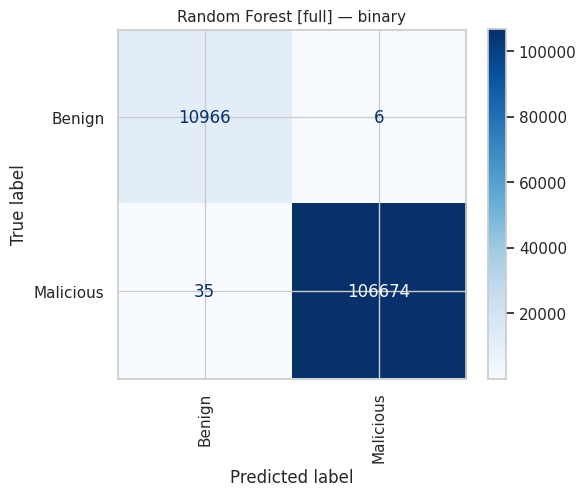

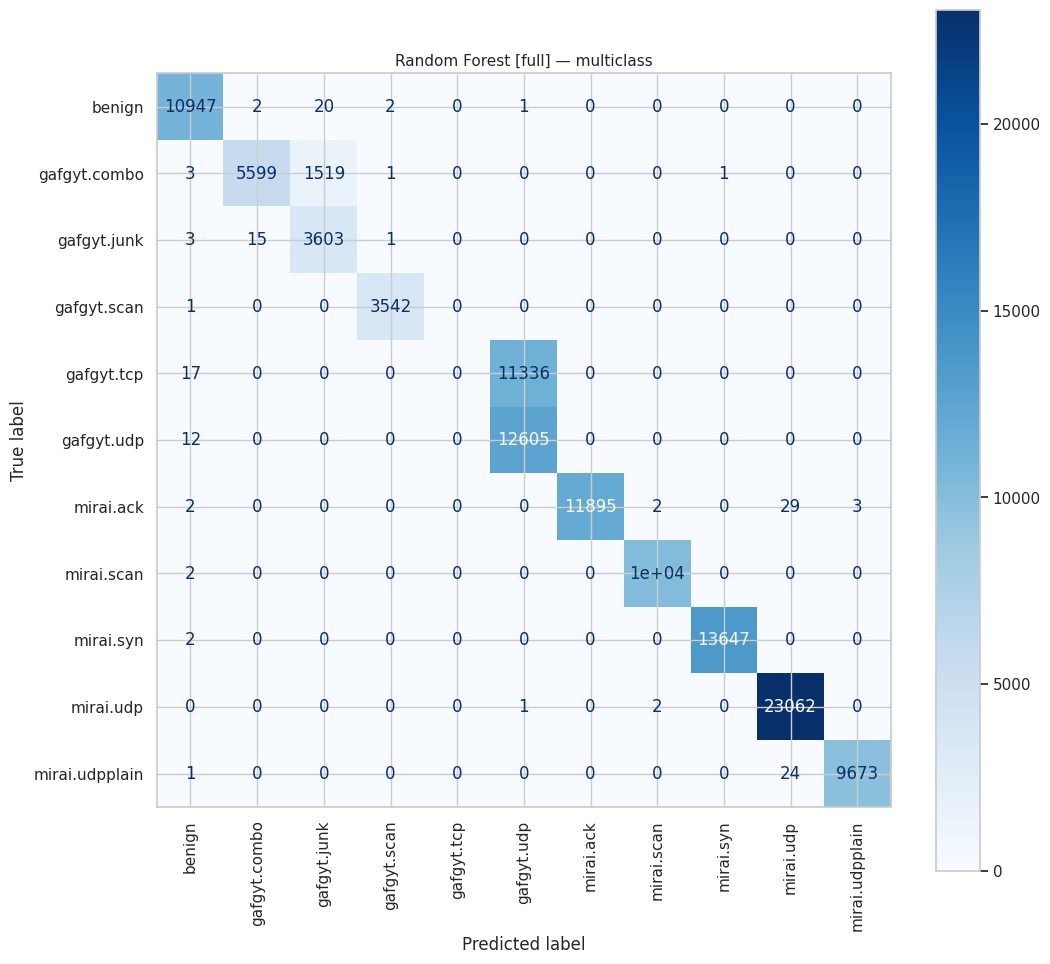

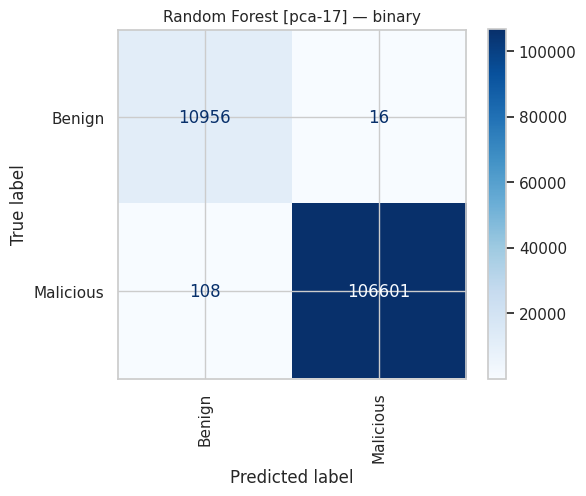

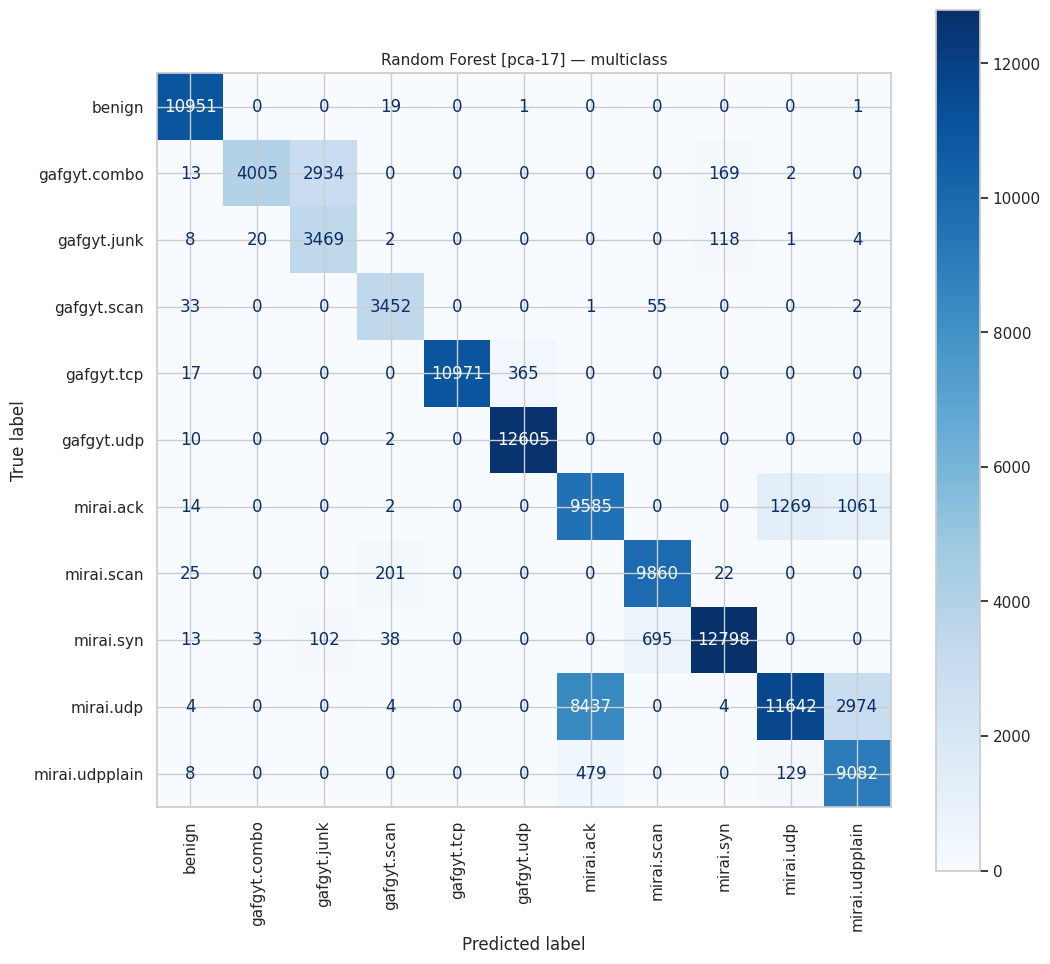

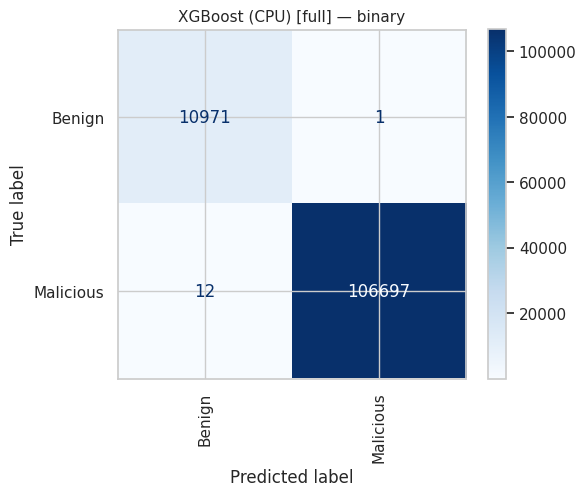

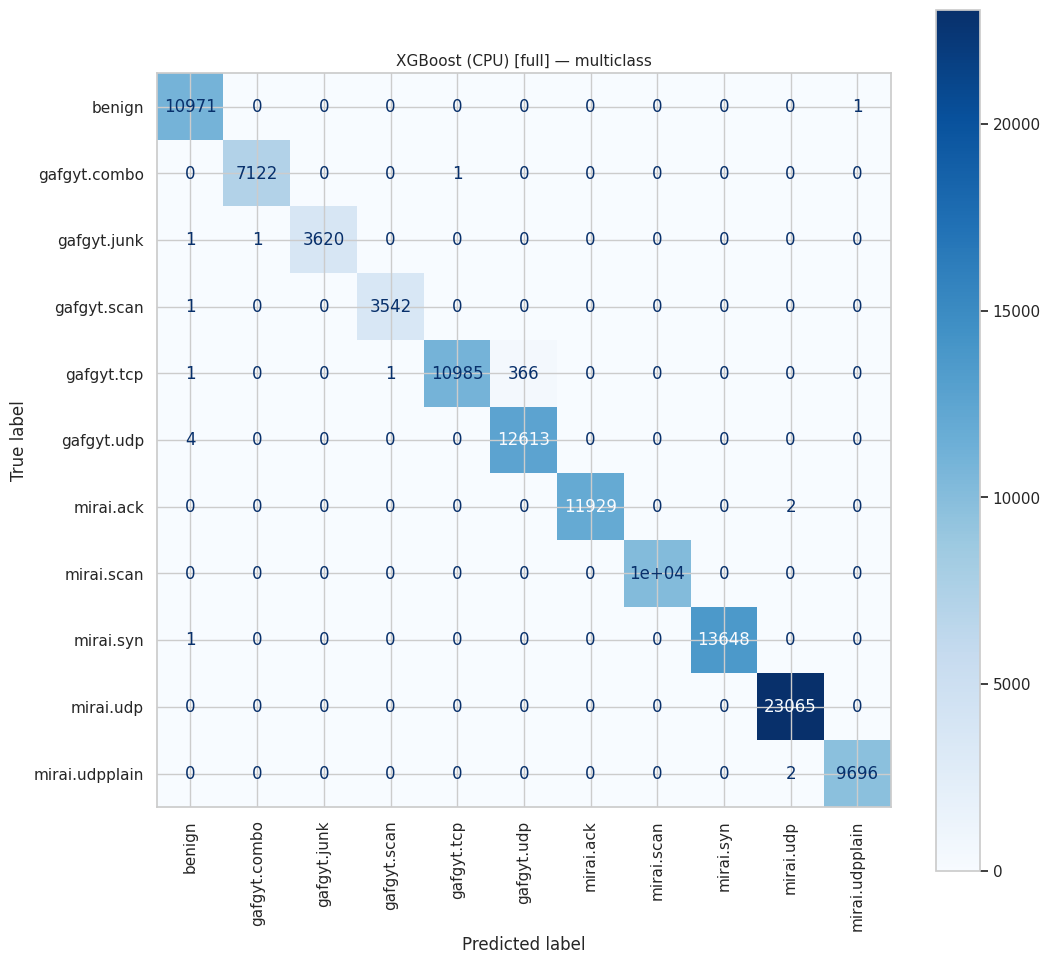

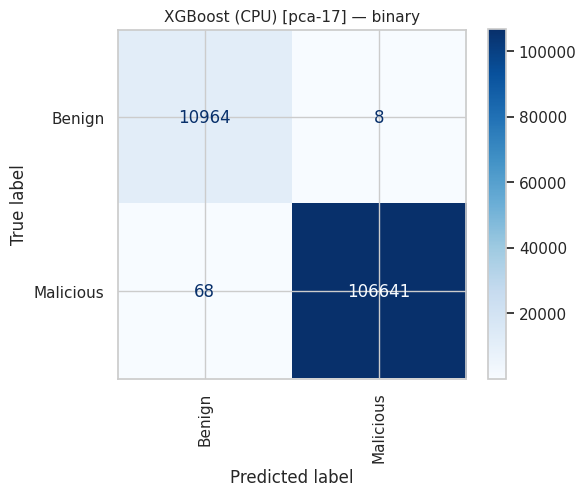

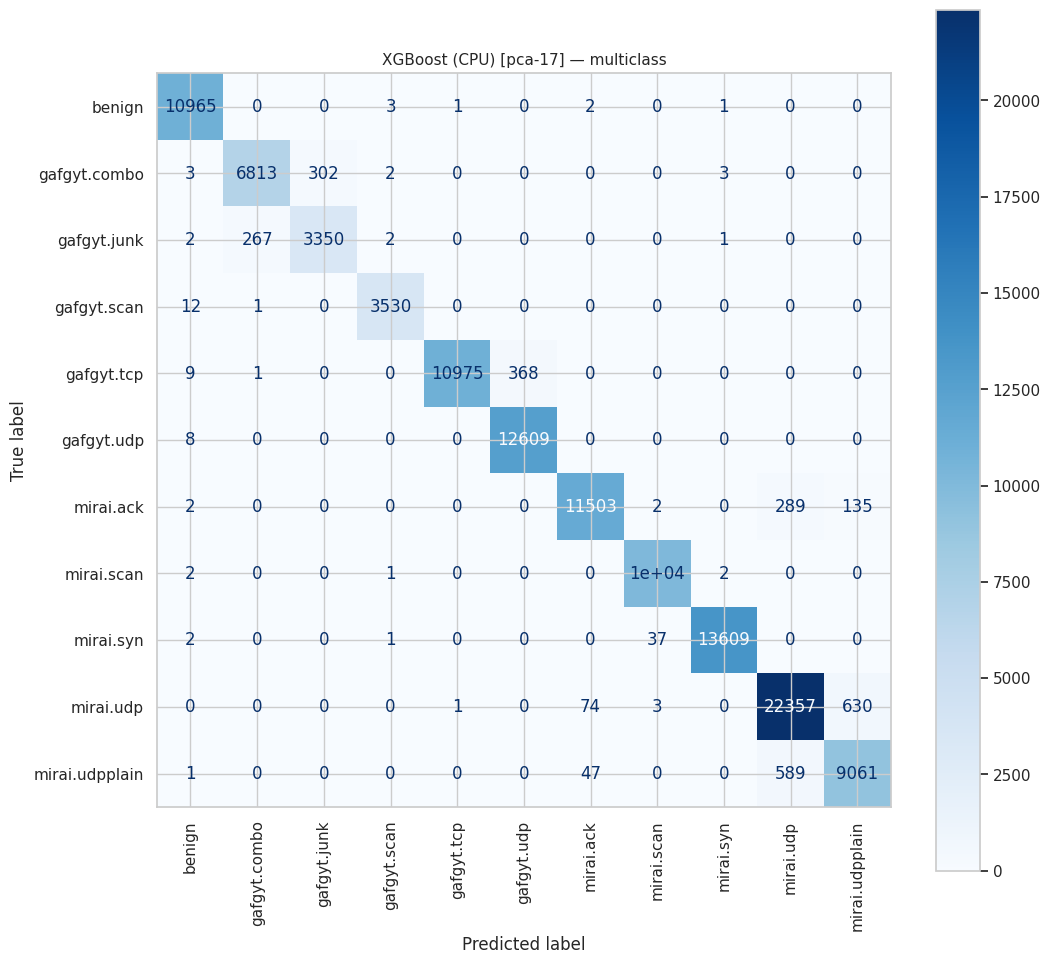

In [11]:
# Получаем тестовые метки из DATASETS
y_test_by_task = {
    task: list(DATASETS.values())[0][task][3]   # y_test — 4-й элемент кортежа
    for task in ["binary", "multiclass"]
}

for algo_name, modes in all_results.items():
    for feature_mode, tasks in modes.items():
        for task, res in tasks.items():

            plot_confusion_matrix(
                y_true      = y_test_by_task[task],
                y_pred      = res["y_pred"],
                class_names = CLASS_NAMES[task],
                title       = f"{algo_name} [{feature_mode}] — {task}"
            )

## 8. Важность признаков

Отображается для всех алгоритмов, у которых есть `feature_importances_`.  
Строится только для режима **full features** (исходные признаки), чтобы сохранить интерпретируемость.

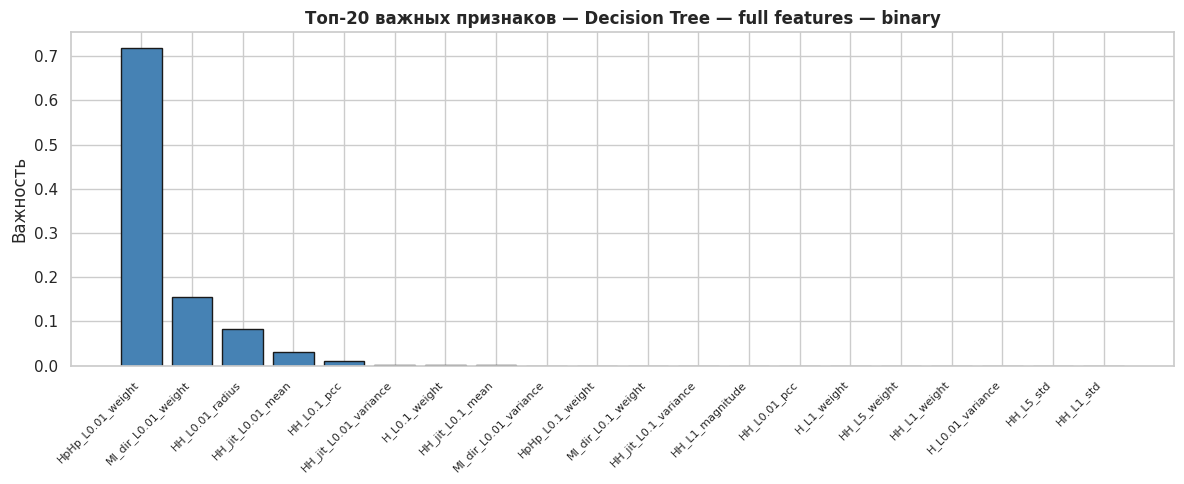

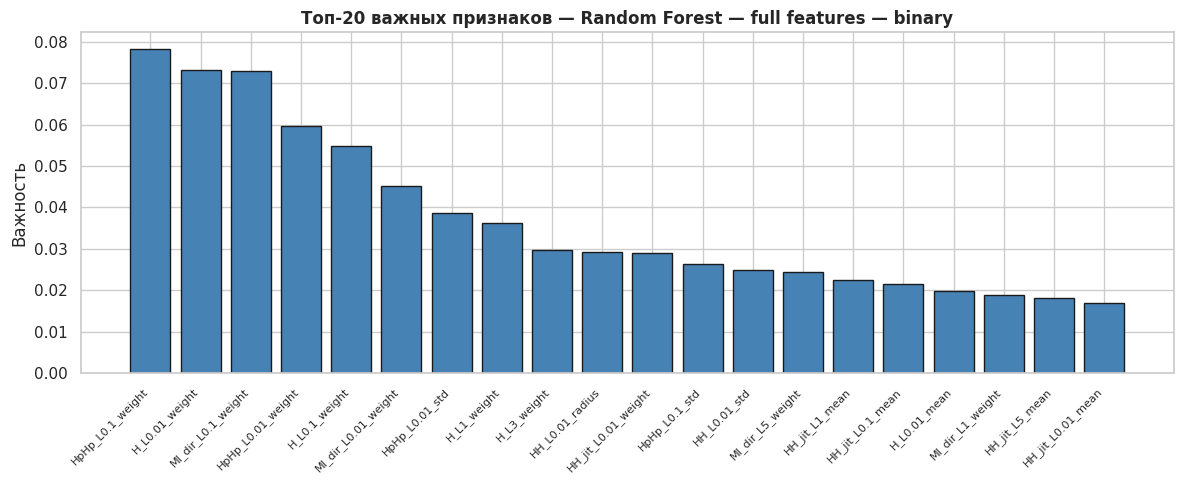

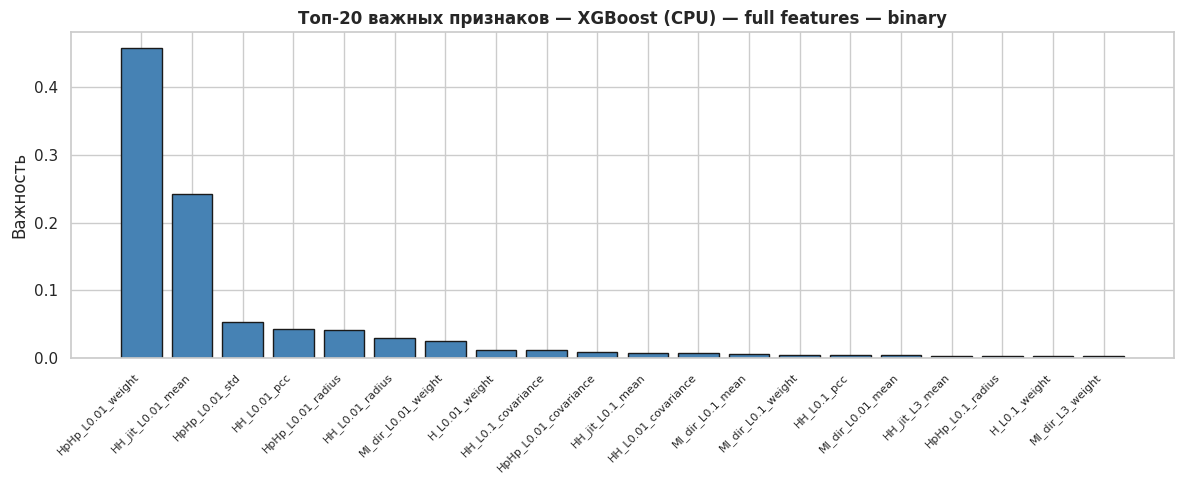

In [12]:
for algo_name, modes in all_results.items():
    # Берём модель, обученную на полных признаках, для бинарной задачи
    trained_model = modes.get("full", {}).get("binary", {}).get("model")

    if trained_model is None:
        continue

    plot_feature_importance(
        model        = trained_model,
        feature_names = FEATURE_COLS,
        title        = f"{algo_name} — full features — binary",
        top_n        = 20,
    )

## 9. Финальный отчёт

In [18]:
MODELS = list(MODELS_run.keys())

print("=" * 72)
print("  ФИНАЛЬНЫЙ ОТЧЁТ")
print("=" * 72)
print(f"  Датасет        : {SAMPLE_FRACTION*100:.0f}% от исходного ({sampled_rows:,} строк)")
print(f"  Train/Test     : {(1-TEST_SIZE)*100:.0f}% / {TEST_SIZE*100:.0f}%")
print(f"  PCA компонент  : {N_PCA_COMPONENTS} (объясн. дисп.: {explained*100:.1f}%)")
print(f"  Алгоритмов     : {len(MODELS)}: {', '.join(MODELS)}")

print("\n── БИНАРНАЯ КЛАССИФИКАЦИЯ ──────────────────────────────────")
print(df_binary.to_string(index=False, float_format="{:.4f}".format))

print("\n── МУЛЬТИКЛАССОВАЯ КЛАССИФИКАЦИЯ ───────────────────────────")
print(df_multiclass.to_string(index=False, float_format="{:.4f}".format))

# Ускорение PCA по задаче binary
print("\n── Ускорение обучения от PCA (full / pca) — бинарная ───────")
pca_mode = f"pca-{N_PCA_COMPONENTS}"
for algo_name in MODELS:
    row_full = df_binary[(df_binary["Алгоритм"]==algo_name) & (df_binary["Признаки"]=="full")]
    row_pca  = df_binary[(df_binary["Алгоритм"]==algo_name) & (df_binary["Признаки"]==pca_mode)]
    if row_full.empty or row_pca.empty:
        continue
    t_full  = row_full["Train time (s)"].values[0]
    t_pca   = row_pca["Train time (s)"].values[0]
    speedup = t_full / t_pca if t_pca > 0 else float("inf")
    delta_acc = (row_pca["Accuracy"].values[0] - row_full["Accuracy"].values[0]) * 100
    sign      = "+" if delta_acc >= 0 else ""
    print(f"  {algo_name:<22}: {t_full:6.2f}с → {t_pca:6.2f}с  "
          f"(x{speedup:.1f} быстрее)  ΔAccuracy={sign}{delta_acc:.2f}pp")

  ФИНАЛЬНЫЙ ОТЧЁТ
  Датасет        : 10% от исходного (588,402 строк)
  Train/Test     : 80% / 20%
  PCA компонент  : 17 (объясн. дисп.: 95.2%)
  Алгоритмов     : 3: Decision Tree, Random Forest, XGBoost (CPU)

── БИНАРНАЯ КЛАССИФИКАЦИЯ ──────────────────────────────────
     Алгоритм Признаки  Accuracy  Precision  Recall  Train time (s)
Decision Tree     full    0.9992     0.9995  0.9997         21.6900
Decision Tree   pca-17    0.9985     0.9999  0.9985          8.0019
Random Forest     full    0.9997     0.9999  0.9997          7.9345
Random Forest   pca-17    0.9989     0.9998  0.9990          8.0000
XGBoost (CPU)     full    0.9999     1.0000  0.9999          1.6967
XGBoost (CPU)   pca-17    0.9994     0.9999  0.9994          0.7058

── МУЛЬТИКЛАССОВАЯ КЛАССИФИКАЦИЯ ───────────────────────────
     Алгоритм Признаки  Accuracy  Precision  Recall  Train time (s)
Decision Tree     full    0.8620     0.8258  0.8620         22.5664
Decision Tree   pca-17    0.7337     0.8630  0.7337   

## 10. График: время обучения vs размер датасета

Визуализирует зависимость времени обучения от доли используемого датасета для каждого алгоритма (full features и PCA), отдельно для бинарной и мультиклассовой задач.

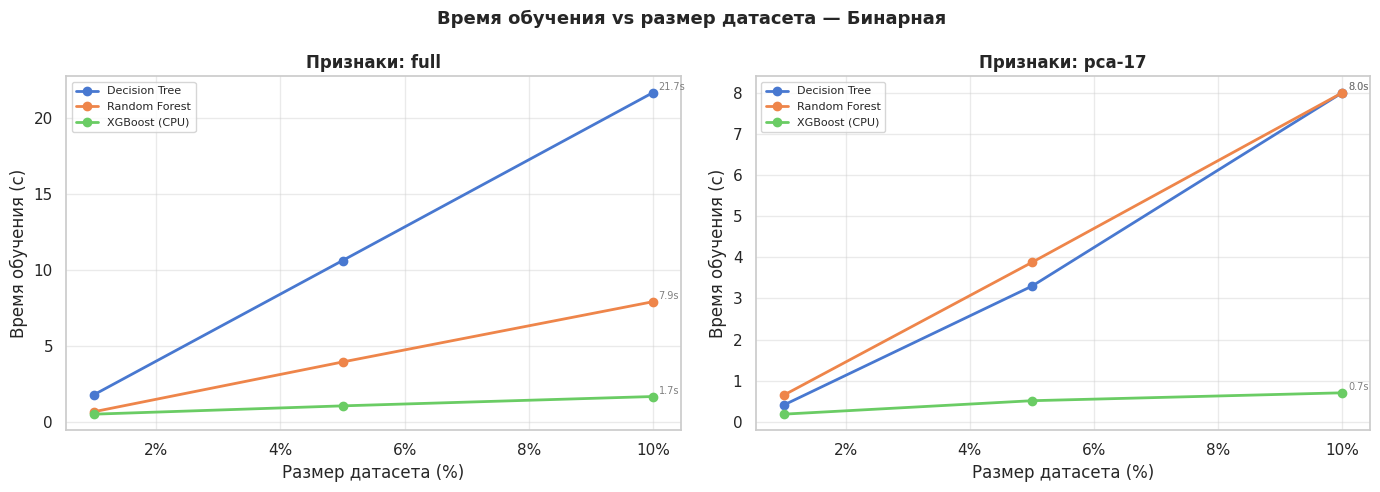

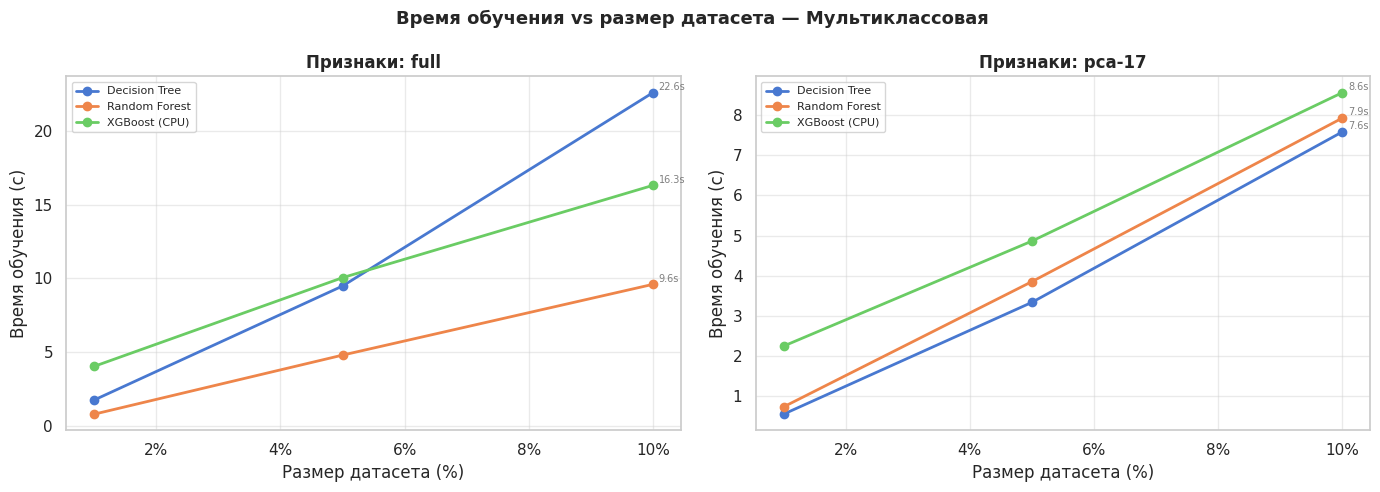


── Время обучения (сек) по прогонам (бинарная, full features) ──
Алгоритм               |     1% |     5% |    10%
----------------------------------------------------
Decision Tree          |   1.82 |  10.64 |  21.69
Random Forest          |   0.70 |   3.97 |   7.93
XGBoost (CPU)          |   0.53 |   1.08 |   1.70


In [25]:
# ╔══════════════════════════════════════════════════════════════╗
# ║        ВРЕМЯ ОБУЧЕНИЯ vs РАЗМЕР ДАТАСЕТА                    ║
# ╚══════════════════════════════════════════════════════════════╝

import matplotlib.ticker as mticker

# Собираем данные из scaling_results
# scaling_results[fraction][algo_name][feature_mode][task] → result_dict

tasks_to_plot = ["binary", "multiclass"]
task_labels   = {"binary": "Бинарная", "multiclass": "Мультиклассовая"}

for task in tasks_to_plot:

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
    fig.suptitle(
        f"Время обучения vs размер датасета — {task_labels[task]}",
        fontsize=13, fontweight="bold"
    )

    feature_modes = list(list(scaling_results.values())[0][list(MODELS_run.keys())[0]].keys())

    for ax, feature_mode in zip(axes, feature_modes):
        for algo_name in MODELS_run:
            fractions = sorted(scaling_results.keys())
            times = [
                scaling_results[frac][algo_name][feature_mode][task]["train_time"]
                for frac in fractions
            ]
            x_vals = [frac * 100 for frac in fractions]  # % датасета
            ax.plot(x_vals, times, marker="o", linewidth=2, label=algo_name)

            # Аннотация последней точки
            ax.annotate(
                f"{times[-1]:.1f}s",
                xy=(x_vals[-1], times[-1]),
                xytext=(4, 2), textcoords="offset points",
                fontsize=7, color="gray"
            )

        ax.set_title(f"Признаки: {feature_mode}", fontweight="bold")
        ax.set_xlabel("Размер датасета (%)")
        ax.set_ylabel("Время обучения (с)")
        ax.legend(fontsize=8)
        ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
        ax.grid(True, alpha=0.4)

    plt.tight_layout()
    plt.show()

# ── Сводная таблица: время обучения по всем прогонам ────────────────────
print("\n── Время обучения (сек) по прогонам (бинарная, full features) ──")
header_fracs = [f"{f*100:.0f}%" for f in sorted(scaling_results.keys())]
print(f"{'Алгоритм':<22} | " + " | ".join(f"{h:>6}" for h in header_fracs))
print("-" * (22 + 3 + 9 * len(header_fracs)))

for algo_name in MODELS_run:
    row_vals = []
    for frac in sorted(scaling_results.keys()):
        t = scaling_results[frac][algo_name]["full"]["binary"]["train_time"]
        row_vals.append(f"{t:6.2f}")
    print(f"{algo_name:<22} | " + " | ".join(row_vals))


## 11. Эксперимент: влияние количества ядер CPU

Фиксируем размер датасета (`CORES_SAMPLE_FRACTION`) и обучаем на разном количестве ядер из `N_JOBS_LIST`.  
**Decision Tree** не поддерживает параллелизм — измеряется один раз как baseline.  
**Random Forest** — `n_jobs`.  
**XGBoost** — `nthread`.  

Результаты сохраняются в `cores_results`.

In [31]:
# ╔══════════════════════════════════════════════════════════════╗
# ║   ЭКСПЕРИМЕНТ: влияние количества ядер CPU на время обучения ║
# ╚══════════════════════════════════════════════════════════════╝

import psutil as _psutil
_phys_cores = _psutil.cpu_count(logical=False)
_logi_cores = _psutil.cpu_count(logical=True)
print(f"Физических ядер: {_phys_cores}  |  Логических: {_logi_cores}")

# Алгоритмы, поддерживающие параллелизм, и способ передачи числа ядер
PARALLEL_MODELS_DEF = {
    "Decision Tree": {
        "constructor": lambda n_jobs, **kw: __import__(
            "sklearn.tree", fromlist=["DecisionTreeClassifier"]
        ).DecisionTreeClassifier(
            max_depth=6, min_samples_leaf=5,
            class_weight="balanced", random_state=RANDOM_STATE
        ),
        "parallel_param": None,   # однопоточный — замеряется только один раз
    },
    "Random Forest": {
        "constructor": lambda n_jobs, **kw: __import__(
            "sklearn.ensemble", fromlist=["RandomForestClassifier"]
        ).RandomForestClassifier(
            n_estimators=100, max_depth=6, min_samples_leaf=5,
            class_weight="balanced", random_state=RANDOM_STATE, n_jobs=n_jobs
        ),
        "parallel_param": "n_jobs",
    },
    "XGBoost (CPU)": {
        "constructor": lambda n_jobs, scale_pos_weight=1, n_classes=2, task="binary", **kw: (
            __import__("xgboost", fromlist=["XGBClassifier"]).XGBClassifier(
                n_estimators=100, max_depth=6, learning_rate=0.1,
                subsample=0.8, colsample_bytree=0.8,
                scale_pos_weight=scale_pos_weight,
                tree_method="hist", device="cpu",
                eval_metric="logloss", random_state=RANDOM_STATE,
                verbosity=0, nthread=n_jobs
            ) if task == "binary" else
            __import__("xgboost", fromlist=["XGBClassifier"]).XGBClassifier(
                n_estimators=100, max_depth=6, learning_rate=0.1,
                subsample=0.8, colsample_bytree=0.8,
                objective="multi:softmax", num_class=n_classes,
                tree_method="hist", device="cpu",
                eval_metric="mlogloss", random_state=RANDOM_STATE,
                verbosity=0, nthread=n_jobs
            )
        ),
        "parallel_param": "nthread",
    },
}

# ── Подготовка данных при фиксированном CORES_SAMPLE_FRACTION ───────────
print(f"\nПодготовка данных: {CORES_SAMPLE_FRACTION*100:.0f}% датасета...")

if CORES_SAMPLE_FRACTION < 1.0:
    _df_c, _ = train_test_split(
        df, train_size=CORES_SAMPLE_FRACTION,
        random_state=RANDOM_STATE, stratify=df["label_binary"]
    )
    _df_c = _df_c.reset_index(drop=True)
else:
    _df_c = df.copy()

_fc = [c for c in _df_c.columns if c not in ("label_binary", "label_multi")]
_df_c = _df_c.drop_duplicates(subset=_fc).reset_index(drop=True)
_std = _df_c[_fc].std()
_fc  = [c for c in _fc if _std[c] != 0]
_df_c[_fc] = _df_c[_fc].fillna(0)

_yb = _df_c["label_binary"].values
_ym = _df_c["label_multi"].values
_le_c = LabelEncoder()
_ym_enc = _le_c.fit_transform(_ym)
_nc   = len(_le_c.classes_)
_bc   = pd.Series(_yb).value_counts()
_spw  = int(_bc[0]) / int(_bc[1])

_Xraw = _df_c[_fc].values.astype(np.float32)
_Xrob = RobustScaler().fit_transform(_Xraw).astype(np.float32)
_Xstd = StandardScaler().fit_transform(_Xraw).astype(np.float64)
_Xpca = PCA(n_components=N_PCA_COMPONENTS, random_state=RANDOM_STATE).fit_transform(_Xstd).astype(np.float32)
del _Xstd, _Xraw

_sk_b = dict(test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=_yb)
_sk_m = dict(test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=_ym_enc)

_Xr_tr_b, _Xr_te_b, _y_tr_b, _y_te_b = train_test_split(_Xrob, _yb,     **_sk_b)
_Xr_tr_m, _Xr_te_m, _y_tr_m, _y_te_m = train_test_split(_Xrob, _ym_enc, **_sk_m)
_Xp_tr_b, _Xp_te_b, _,       _        = train_test_split(_Xpca, _yb,     **_sk_b)
_Xp_tr_m, _Xp_te_m, _,       _        = train_test_split(_Xpca, _ym_enc, **_sk_m)

_DATASETS_C = {
    "full":              {"binary": (_Xr_tr_b, _Xr_te_b, _y_tr_b, _y_te_b),
                          "multiclass": (_Xr_tr_m, _Xr_te_m, _y_tr_m, _y_te_m)},
    f"pca-{N_PCA_COMPONENTS}": {"binary": (_Xp_tr_b, _Xp_te_b, _y_tr_b, _y_te_b),
                                "multiclass": (_Xp_tr_m, _Xp_te_m, _y_tr_m, _y_te_m)},
}
print(f"  Train: {len(_Xr_tr_b):,} строк  |  Test: {len(_Xr_te_b):,} строк")

# ── Основной цикл: n_jobs ─────────────────────────────────────────────────
# cores_results[n_jobs][algo_name][feature_mode][task] → train_time
cores_results = {}

for n_jobs in N_JOBS_LIST:

    label = f"all ({_logi_cores})" if n_jobs == -1 else str(n_jobs)
    print(f"\n{'='*55}")
    print(f"  Ядра: {label}")
    print(f"{'='*55}")

    cores_results[n_jobs] = {}

    for algo_name, algo_def in PARALLEL_MODELS_DEF.items():

        cores_results[n_jobs][algo_name] = {}
        is_parallel = algo_def["parallel_param"] is not None

        for feature_mode, task_data in _DATASETS_C.items():
            cores_results[n_jobs][algo_name][feature_mode] = {}

            for task, (X_tr, X_te, y_tr, y_te) in task_data.items():
                if task == "binary":
                    model = algo_def["constructor"](n_jobs=n_jobs, scale_pos_weight=_spw, task=task)
                else:
                    model = algo_def["constructor"](n_jobs=n_jobs, n_classes=_nc, task=task)

                m = clone(model)
                t0 = time.perf_counter()
                m.fit(X_tr, y_tr)
                elapsed = time.perf_counter() - t0
                cores_results[n_jobs][algo_name][feature_mode][task] = elapsed
                print(f"  [{feature_mode}] {algo_name}/{task}: {elapsed:.3f}s")

gc.collect()
print("\n✓ Эксперимент с ядрами завершён.")

Физических ядер: 16  |  Логических: 32

Подготовка данных: 5% датасета...
  Train: 256,576 строк  |  Test: 64,145 строк

  Ядра: 1
  [full] Decision Tree/binary: 11.552s
  [full] Decision Tree/multiclass: 11.526s
  [pca-17] Decision Tree/binary: 3.613s
  [pca-17] Decision Tree/multiclass: 3.879s
  [full] Random Forest/binary: 51.641s
  [full] Random Forest/multiclass: 64.189s
  [pca-17] Random Forest/binary: 53.260s
  [pca-17] Random Forest/multiclass: 54.309s
  [full] XGBoost (CPU)/binary: 5.802s
  [full] XGBoost (CPU)/multiclass: 72.151s
  [pca-17] XGBoost (CPU)/binary: 1.813s
  [pca-17] XGBoost (CPU)/multiclass: 26.932s

  Ядра: 2
  [full] Decision Tree/binary: 10.714s
  [full] Decision Tree/multiclass: 10.294s
  [pca-17] Decision Tree/binary: 3.581s
  [pca-17] Decision Tree/multiclass: 3.597s
  [full] Random Forest/binary: 24.898s
  [full] Random Forest/multiclass: 32.719s
  [pca-17] Random Forest/binary: 27.885s
  [pca-17] Random Forest/multiclass: 27.802s
  [full] XGBoost (CPU)/b

## 12. График: время обучения vs количество ядер

Ускорение параллельных алгоритмов при увеличении числа ядер.  
**Decision Tree** отображается как горизонтальная пунктирная линия (baseline, однопоточный).  
Левая колонка — полные признаки (`full`), правая — PCA.

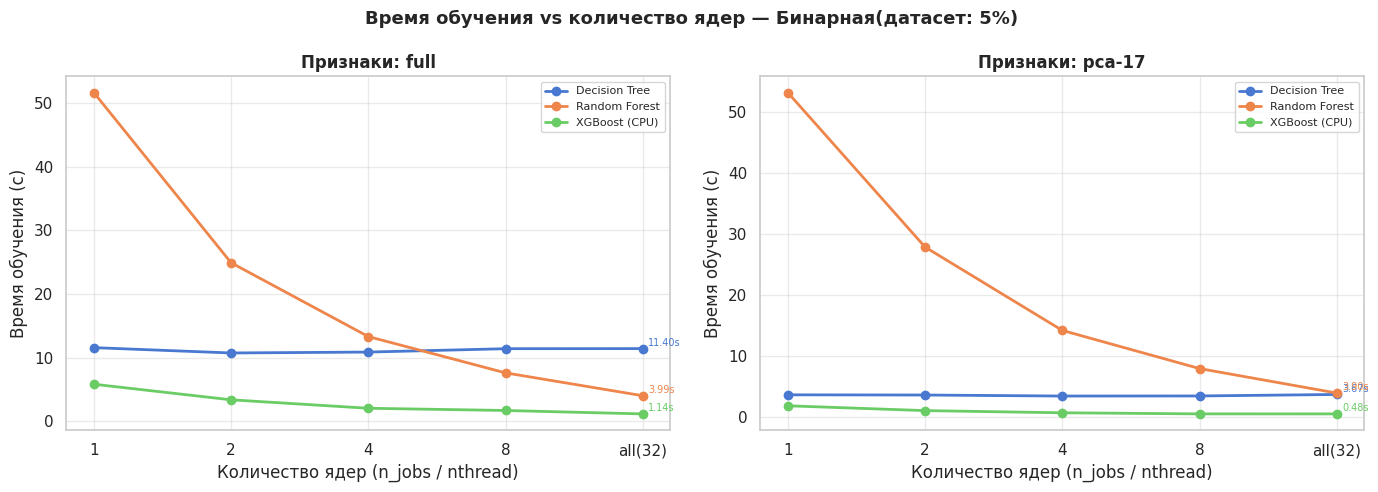

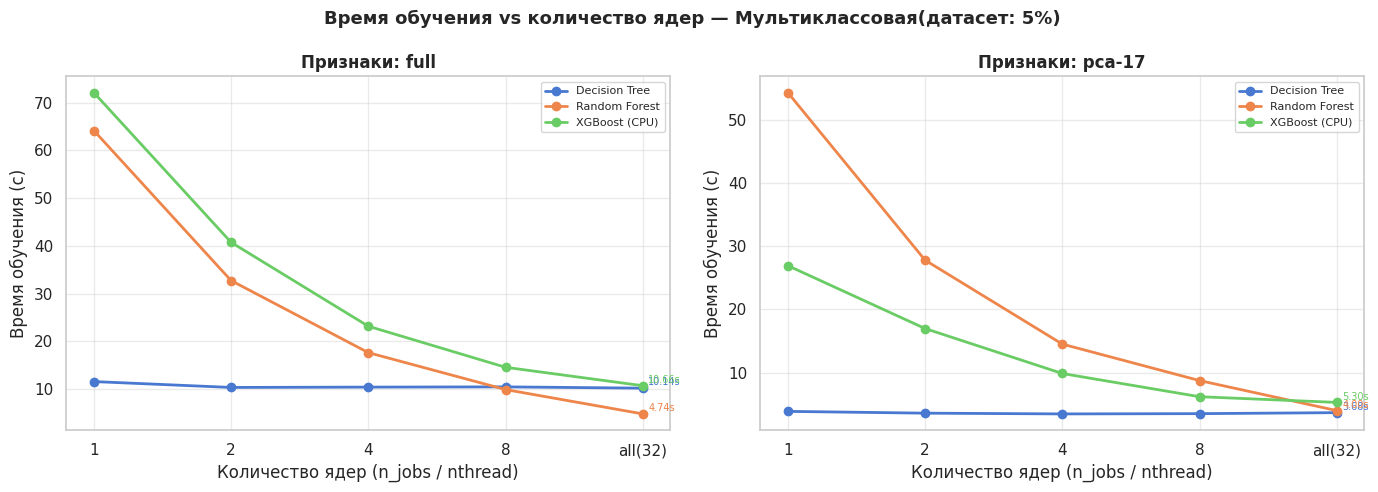


── Ускорение (speedup vs 1 ядро) — full features, бинарная ──────
Алгоритм                       1         2         4         8   all(32)
--------------------------------------------------------------------------
Decision Tree           x  1.00  x  1.08  x  1.06  x  1.01  x  1.01
Random Forest           x  1.00  x  2.07  x  3.89  x  6.81  x 12.93
XGBoost (CPU)           x  1.00  x  1.73  x  2.87  x  3.46  x  5.11

── Абсолютное время (с) — full features, бинарная ─────────────
Алгоритм                       1         2         4         8   all(32)
--------------------------------------------------------------------------
Decision Tree             11.552    10.714    10.855    11.385    11.401
Random Forest             51.641    24.898    13.292     7.588     3.993
XGBoost (CPU)              5.802     3.352     2.025     1.675     1.136


In [37]:
# ╔══════════════════════════════════════════════════════════════╗
# ║     ГРАФИК: ВРЕМЯ ОБУЧЕНИЯ vs КОЛИЧЕСТВО ЯДЕР               ║
# ╚══════════════════════════════════════════════════════════════╝

import psutil as _psutil
_logi_cores = _psutil.cpu_count(logical=True)

def _cores_label(n):
    """Человекочитаемая метка для оси X."""
    return f"all({_logi_cores})" if n == -1 else str(n)

_algos = [a for a, d in PARALLEL_MODELS_DEF.items()]

_feature_modes  = list(list(cores_results.values())[0][_algos[0]].keys())
_tasks          = ["binary", "multiclass"]
_task_labels    = {"binary": "Бинарная", "multiclass": "Мультиклассовая"}

_sorted_jobs    = sorted(cores_results.keys(), key=lambda x: _logi_cores if x == -1 else x)
_x_labels       = [_cores_label(n) for n in _sorted_jobs]
_x_pos          = list(range(len(_sorted_jobs)))

COLORS = plt.rcParams["axes.prop_cycle"].by_key()["color"]

for task in _tasks:
    fig, axes = plt.subplots(1, len(_feature_modes),
                              figsize=(7 * len(_feature_modes), 5), sharey=False)
    if len(_feature_modes) == 1:
        axes = [axes]

    fig.suptitle(
        f"Время обучения vs количество ядер — {_task_labels[task]}"
        f"(датасет: {CORES_SAMPLE_FRACTION*100:.0f}%)",
        fontsize=13, fontweight="bold"
    )

    for ax, fmode in zip(axes, _feature_modes):
        for ci, algo_name in enumerate(_algos):
            times = [cores_results[n][algo_name][fmode][task] for n in _sorted_jobs]
            ax.plot(_x_pos, times, marker="o", linewidth=2,
                    label=algo_name, color=COLORS[ci])

            # Аннотация финального значения
            ax.annotate(f"{times[-1]:.2f}s",
                        xy=(_x_pos[-1], times[-1]),
                        xytext=(4, 2), textcoords="offset points",
                        fontsize=7, color=COLORS[ci])

        ax.set_title(f"Признаки: {fmode}", fontweight="bold")
        ax.set_xlabel("Количество ядер (n_jobs / nthread)")
        ax.set_ylabel("Время обучения (с)")
        ax.set_xticks(_x_pos)
        ax.set_xticklabels(_x_labels)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.4)

    plt.tight_layout()
    plt.show()

# ── Ускорение относительно 1 ядра ────────────────────────────────────────
print("\n── Ускорение (speedup vs 1 ядро) — full features, бинарная ──────")
_base_n = _sorted_jobs[0]   # минимальное кол-во ядер (обычно 1)
header = "  ".join(f"{_cores_label(n):>8}" for n in _sorted_jobs)
print(f"{'Алгоритм':<22}  {header}")
print("-" * (22 + 2 + 10 * len(_sorted_jobs)))

for algo_name in _algos:
    t_base = cores_results[_base_n][algo_name]["full"]["binary"]
    row = "  ".join(
        f"x{t_base / cores_results[n][algo_name]['full']['binary']:>6.2f}"
        for n in _sorted_jobs
    )
    print(f"{algo_name:<22}  {row}")

# ── Сводная таблица: абсолютное время ────────────────────────────────────
print("\n── Абсолютное время (с) — full features, бинарная ─────────────")
print(f"{'Алгоритм':<22}  {header}")
print("-" * (22 + 2 + 10 * len(_sorted_jobs)))

for algo_name in list(PARALLEL_MODELS_DEF.keys()):
    row = "  ".join(
        f"{cores_results[n][algo_name]['full']['binary']:>8.3f}"
        for n in _sorted_jobs
    )
    print(f"{algo_name:<22}  {row}")
